# Day 1 - EDA: Weekly Time Series Analysis

## Objective

The goal of this notebook is to complete **Task E-01** of the ArtiLogix project.

Objectives:

- Convert order-level data into weekly aggregates
- Build weekly demand time series for each region
- Identify missing weeks (data gaps)
- Explore regional demand behaviour
- Prepare the dataset for Seasonality Analysis (E-02) and ADF Stationarity Test (E-03)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
current_dir = Path.cwd()
if current_dir.name == 'eda':
    DATA_PATH = current_dir.parent / 'data' / 'orders.parquet'
    OUTPUT_DIR = current_dir.parent / 'outputs'
else:
    DATA_PATH = current_dir / 'data' / 'orders.parquet'
    OUTPUT_DIR = current_dir / 'outputs'

orders = pd.read_parquet(DATA_PATH)
orders['created_at'] = pd.to_datetime(orders['created_at'])
orders['week'] = orders['created_at'].dt.to_period('W').apply(lambda r: r.start_time)

## Initial Data Quality Check

Before creating weekly time series, we perform a quick inspection of the raw dataset to ensure there are no obvious issues such as missing values or duplicated rows.

In [2]:
print("Dataset Shape")

print(orders.shape)

print("\nMissing Values")
print(orders.isna().sum())

print("\nDuplicate Rows")
print(orders.duplicated().sum())

Dataset Shape
(110000, 7)

Missing Values
order_id         0
region           0
item_count       0
created_at       0
delivery_type    0
shipment_id      0
week             0
dtype: int64

Duplicate Rows
0


In [3]:
weekly = (
    orders
    .groupby(['region', 'week'])
    .size()
    .reset_index(name='order_count')
    .sort_values(['region', 'week'])
    .reset_index(drop=True)
)

print(f"Shape      : {weekly.shape}")
print(f"Regionlar  : {sorted(weekly['region'].unique())}")
print(f"Tarix aralığı: {weekly['week'].min().date()} → {weekly['week'].max().date()}")
print(f"\n{weekly['order_count'].describe().round(2)}")

Shape      : (3340, 3)
Regionlar  : ['Absheron', 'Ganja', 'Kalbajar', 'Khachmaz', 'Khankendi', 'Lankaran', 'Nakhchivan', 'Qazakh', 'Sheki', 'Yevlakh']
Tarix aralığı: 2019-12-30 → 2026-06-08

count    3340.00
mean       32.93
std        41.14
min         1.00
25%         9.00
50%        19.00
75%        38.00
max       201.00
Name: order_count, dtype: float64


In [4]:
all_weeks = pd.date_range(weekly['week'].min(), weekly['week'].max(), freq='W-MON')
regions   = weekly['region'].unique()

missing = []
for region in regions:
    reg_weeks = set(weekly[weekly['region'] == region]['week'])
    for w in all_weeks:
        if w not in reg_weeks:
            missing.append({'region': region, 'week': w})

missing_df = pd.DataFrame(missing)

if len(missing_df) == 0:
    print("No gaps found — all region × week pairs are complete.")
else:
    print(f"Number of missing gaps: {len(missing_df)}")
    print(missing_df.groupby('region').size().reset_index(name='missing_weeks'))

weekly['order_count'] = weekly['order_count'].fillna(0)

print(f"NaN count: {weekly['order_count'].isnull().sum()}") 
print(weekly[weekly['region'] == 'Kalbajar'].head())

Number of missing gaps: 30
     region  missing_weeks
0  Kalbajar             29
1   Yevlakh              1
NaN count: 0
       region       week  order_count
674  Kalbajar 2019-12-30            2
675  Kalbajar 2020-01-06            3
676  Kalbajar 2020-01-13            1
677  Kalbajar 2020-01-20            3
678  Kalbajar 2020-01-27            2


## Data Gap Interpretation

Missing weeks do not necessarily indicate data corruption.

Possible reasons include:

- No customer orders during that week
- Delayed data collection
- Missing historical records
- Data ingestion issues

These gaps should be considered during forecasting because they may affect seasonality and trend estimation.

In [5]:
stats = (
    weekly
    .groupby('region')['order_count']
    .agg(
        həftə_sayı  = 'count',
        orta        = 'mean',
        std         = 'std',
        min         = 'min',
        max         = 'max',
        cv          = lambda x: x.std() / x.mean()
    )
    .round(2)
    .sort_values('orta', ascending=False)
)

print(stats.to_string())

            həftə_sayı    orta    std  min  max    cv
region                                               
Absheron           337  147.34  16.60   96  201  0.11
Ganja              337   46.22   7.55   24   82  0.16
Nakhchivan         337   40.14   7.41   23   80  0.18
Sheki              337   23.06   5.00    9   38  0.22
Khachmaz           337   18.10   4.54    4   31  0.25
Lankaran           337   17.39   4.58    5   33  0.26
Qazakh             337   17.30   4.31    7   33  0.25
Khankendi          337    8.33   3.24    1   18  0.39
Yevlakh            336    6.32   2.49    2   13  0.39
Kalbajar           308    2.45   1.31    1    7  0.54


## Sparse Region Detection

Regions with consistently low weekly order volumes may require a different modelling strategy.

These regions will be reviewed in Task E-04 where small regions may be grouped together before model training.

In [6]:
print("Average Weekly Orders Per Region")


avg_orders = (
    weekly
    .groupby("region")["order_count"]
    .mean()
    .sort_values()
)

display(avg_orders)

print("\nPotential Sparse Regions (<10 orders/week):")

sparse_regions = avg_orders[avg_orders < 10]

if sparse_regions.empty:
    print("No sparse regions found.")
else:
    display(sparse_regions)

Average Weekly Orders Per Region


region
Kalbajar        2.451299
Yevlakh         6.318452
Khankendi       8.326409
Qazakh         17.302671
Lankaran       17.388724
Khachmaz       18.103858
Sheki          23.056380
Nakhchivan     40.139466
Ganja          46.216617
Absheron      147.335312
Name: order_count, dtype: float64


Potential Sparse Regions (<10 orders/week):


region
Kalbajar     2.451299
Yevlakh      6.318452
Khankendi    8.326409
Name: order_count, dtype: float64

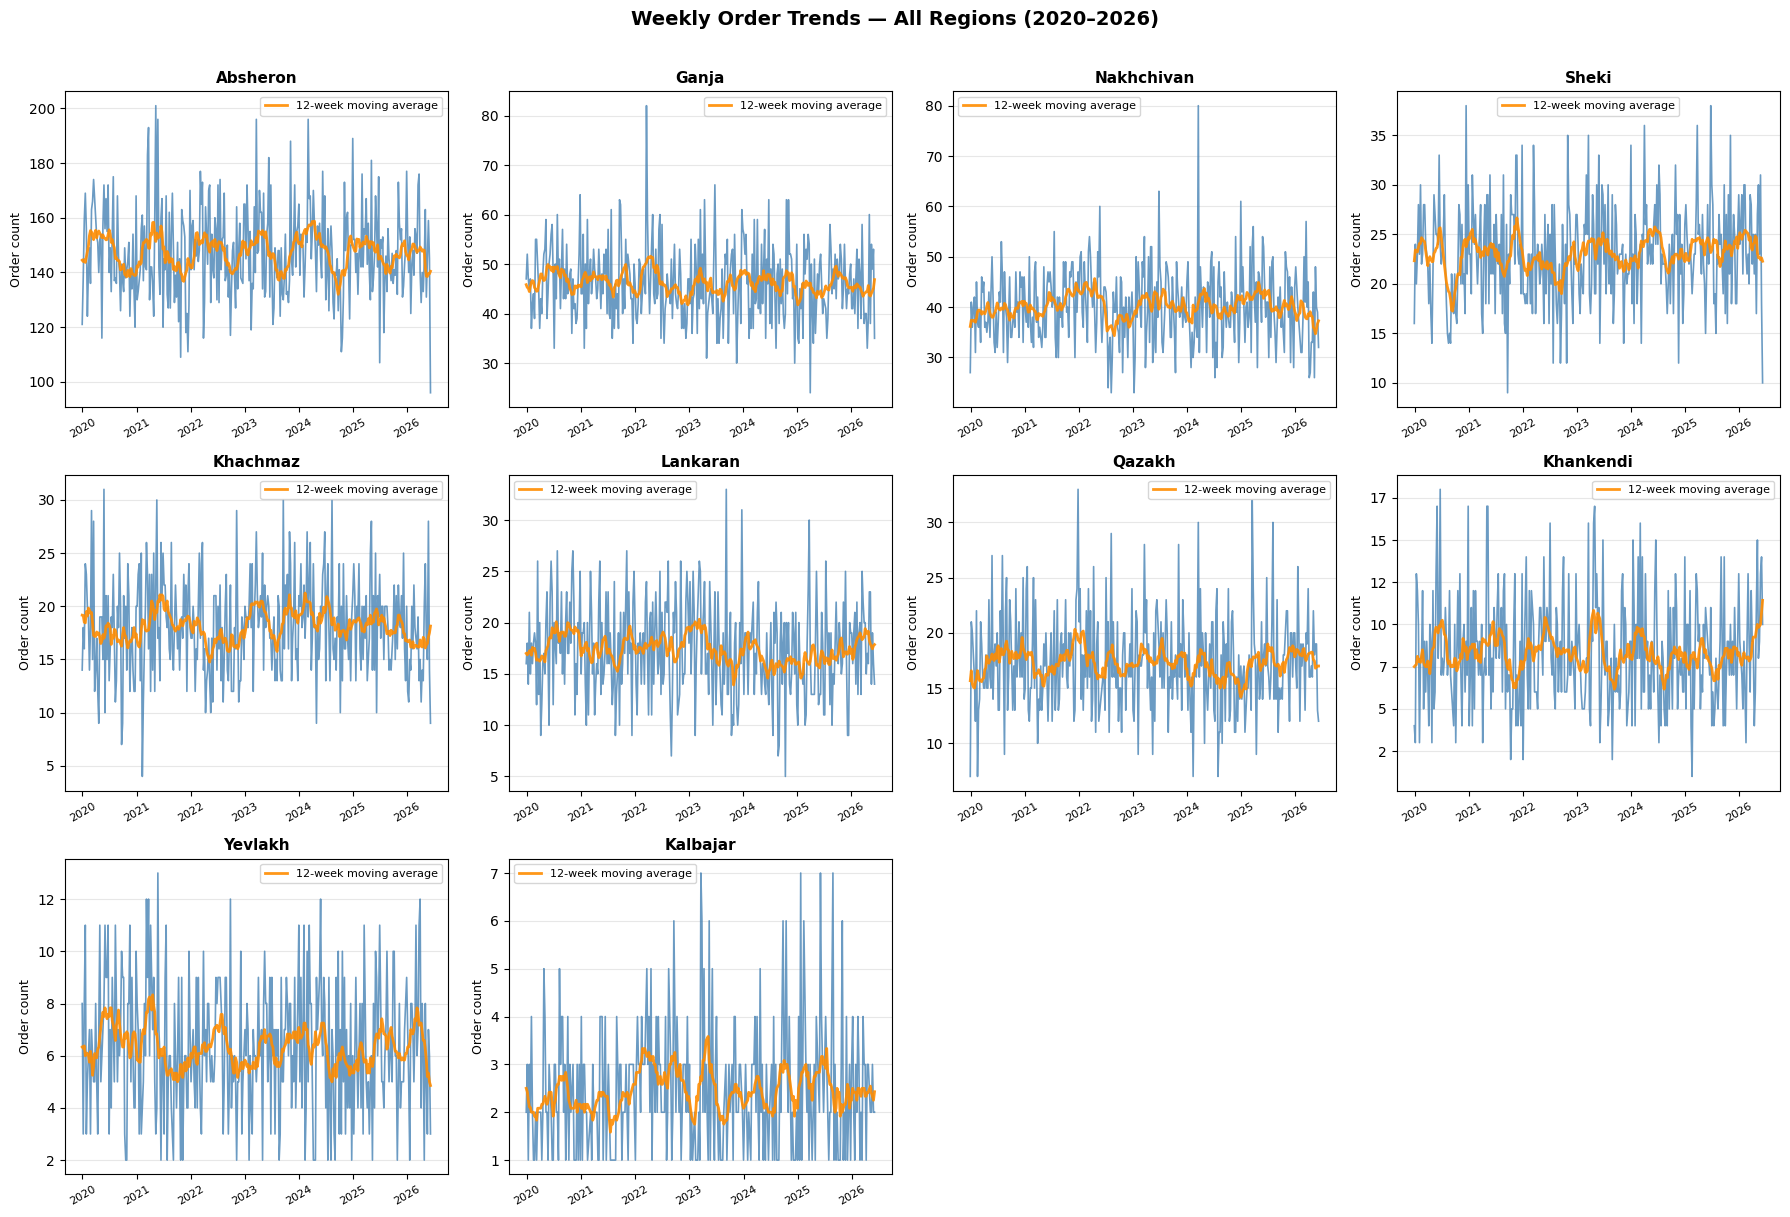

In [7]:
regions_sorted = stats.index.tolist()

fig, axes = plt.subplots(3,4, figsize=(18, 12))
fig.suptitle('Weekly Order Trends — All Regions (2020–2026)',
             fontsize=14, fontweight='bold', y=1.01)

axes_flat = axes.flatten()

for i, region in enumerate(regions_sorted):
    ax  = axes_flat[i]
    sub = weekly[weekly['region'] == region].sort_values('week')

    ax.plot(sub['week'], sub['order_count'],
            linewidth=1.2, color='steelblue', alpha=0.8)

    rolling = sub['order_count'].rolling(12, center=True, min_periods=4).mean()
    ax.plot(sub['week'], rolling,
            linewidth=2, color='darkorange', alpha=0.9, label='12-week moving average')

    ax.set_title(f"{region}", fontsize=11, fontweight='bold')
    ax.set_ylabel('Order count', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}'))
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

for j in range(len(regions_sorted), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

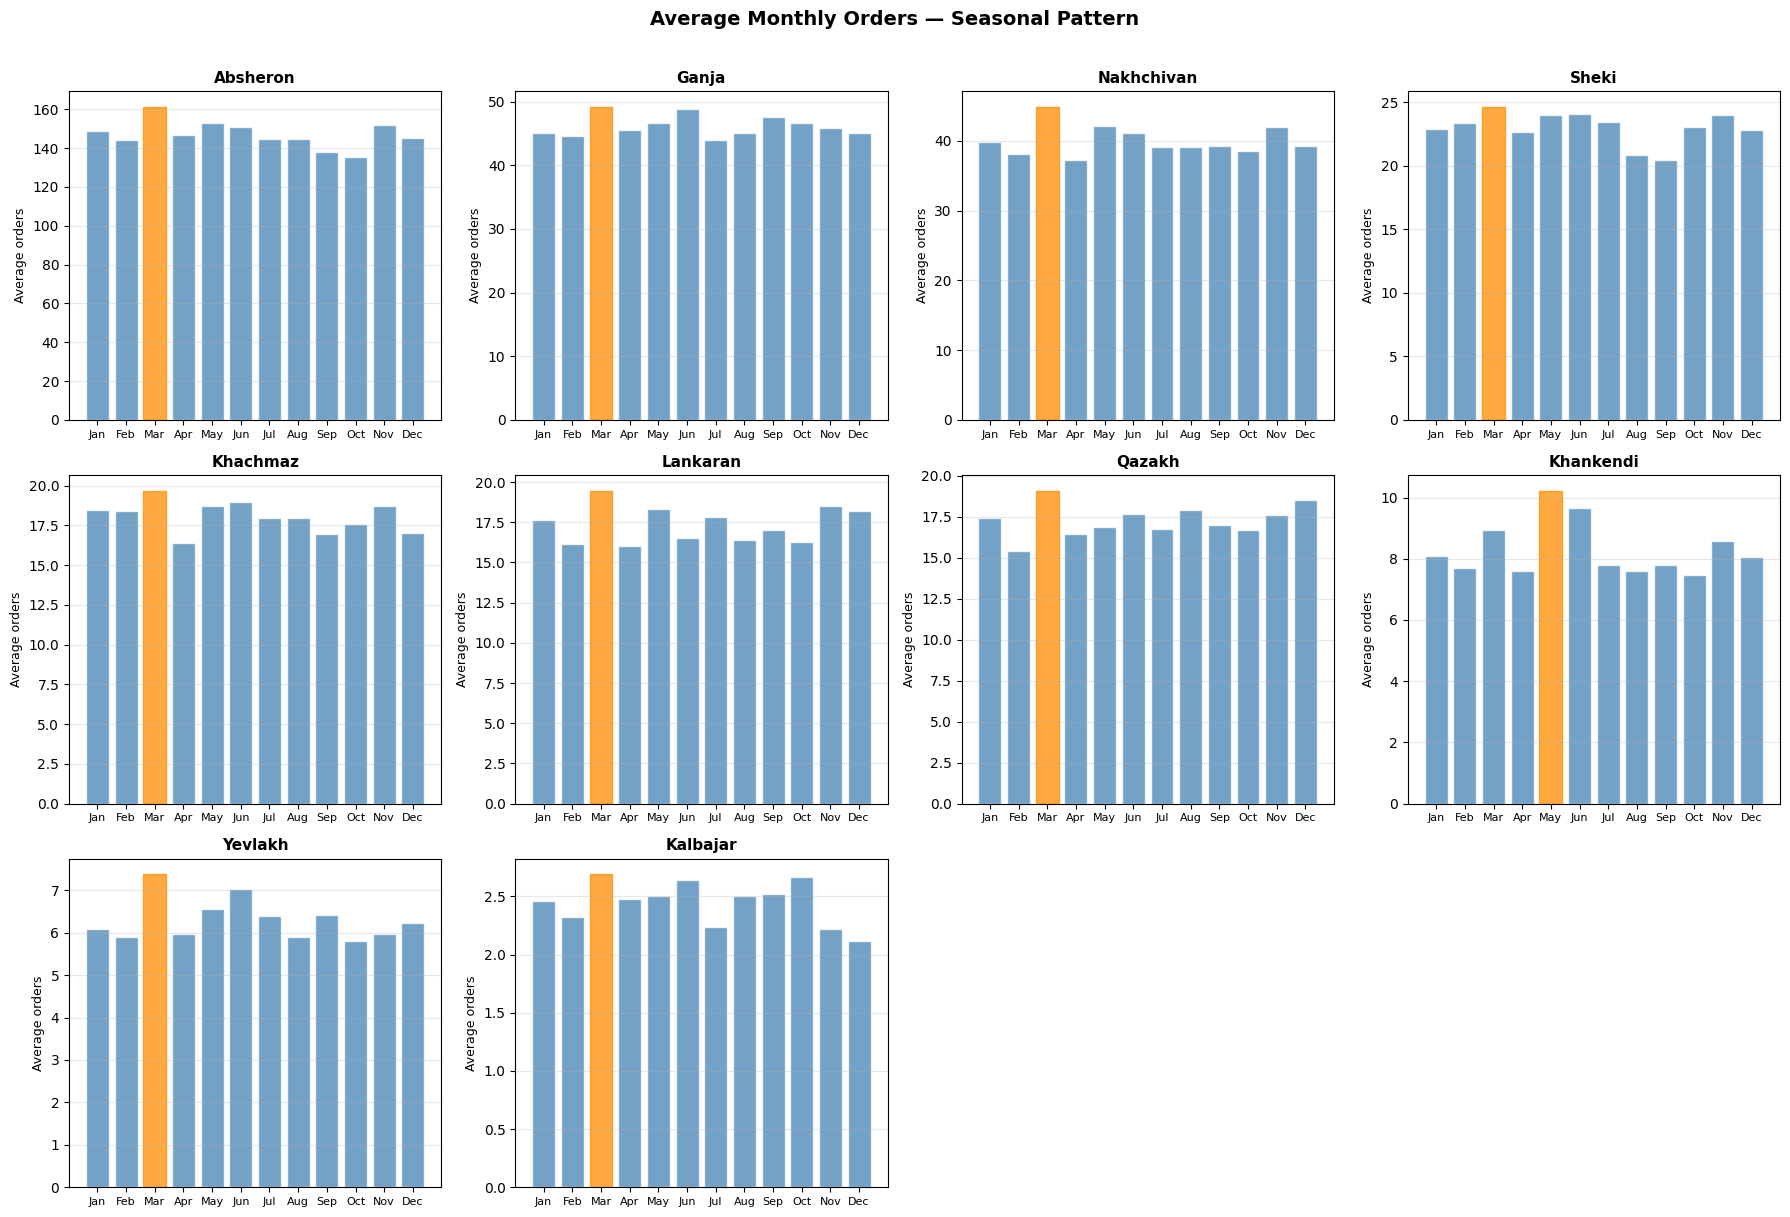

In [8]:
weekly['month'] = weekly['week'].dt.month
monthly_avg = (
    weekly
    .groupby(['region', 'month'])['order_count']
    .mean()
    .reset_index()
)

month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
monthly_avg['month_name'] = monthly_avg['month'].map(month_names)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Average Monthly Orders — Seasonal Pattern',
             fontsize=14, fontweight='bold', y=1.01)

axes_flat = axes.flatten()

for i, region in enumerate(regions_sorted):
    ax  = axes_flat[i]
    sub = monthly_avg[monthly_avg['region'] == region].sort_values('month')

    bars = ax.bar(sub['month_name'], sub['order_count'],
                  color='steelblue', alpha=0.75, edgecolor='white')

    peak_idx = sub['order_count'].idxmax()
    bars[sub.index.get_loc(peak_idx)].set_color('darkorange')

    ax.set_title(region, fontsize=11, fontweight='bold')
    ax.set_ylabel('Average orders', fontsize=9)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)

for j in range(len(regions_sorted), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

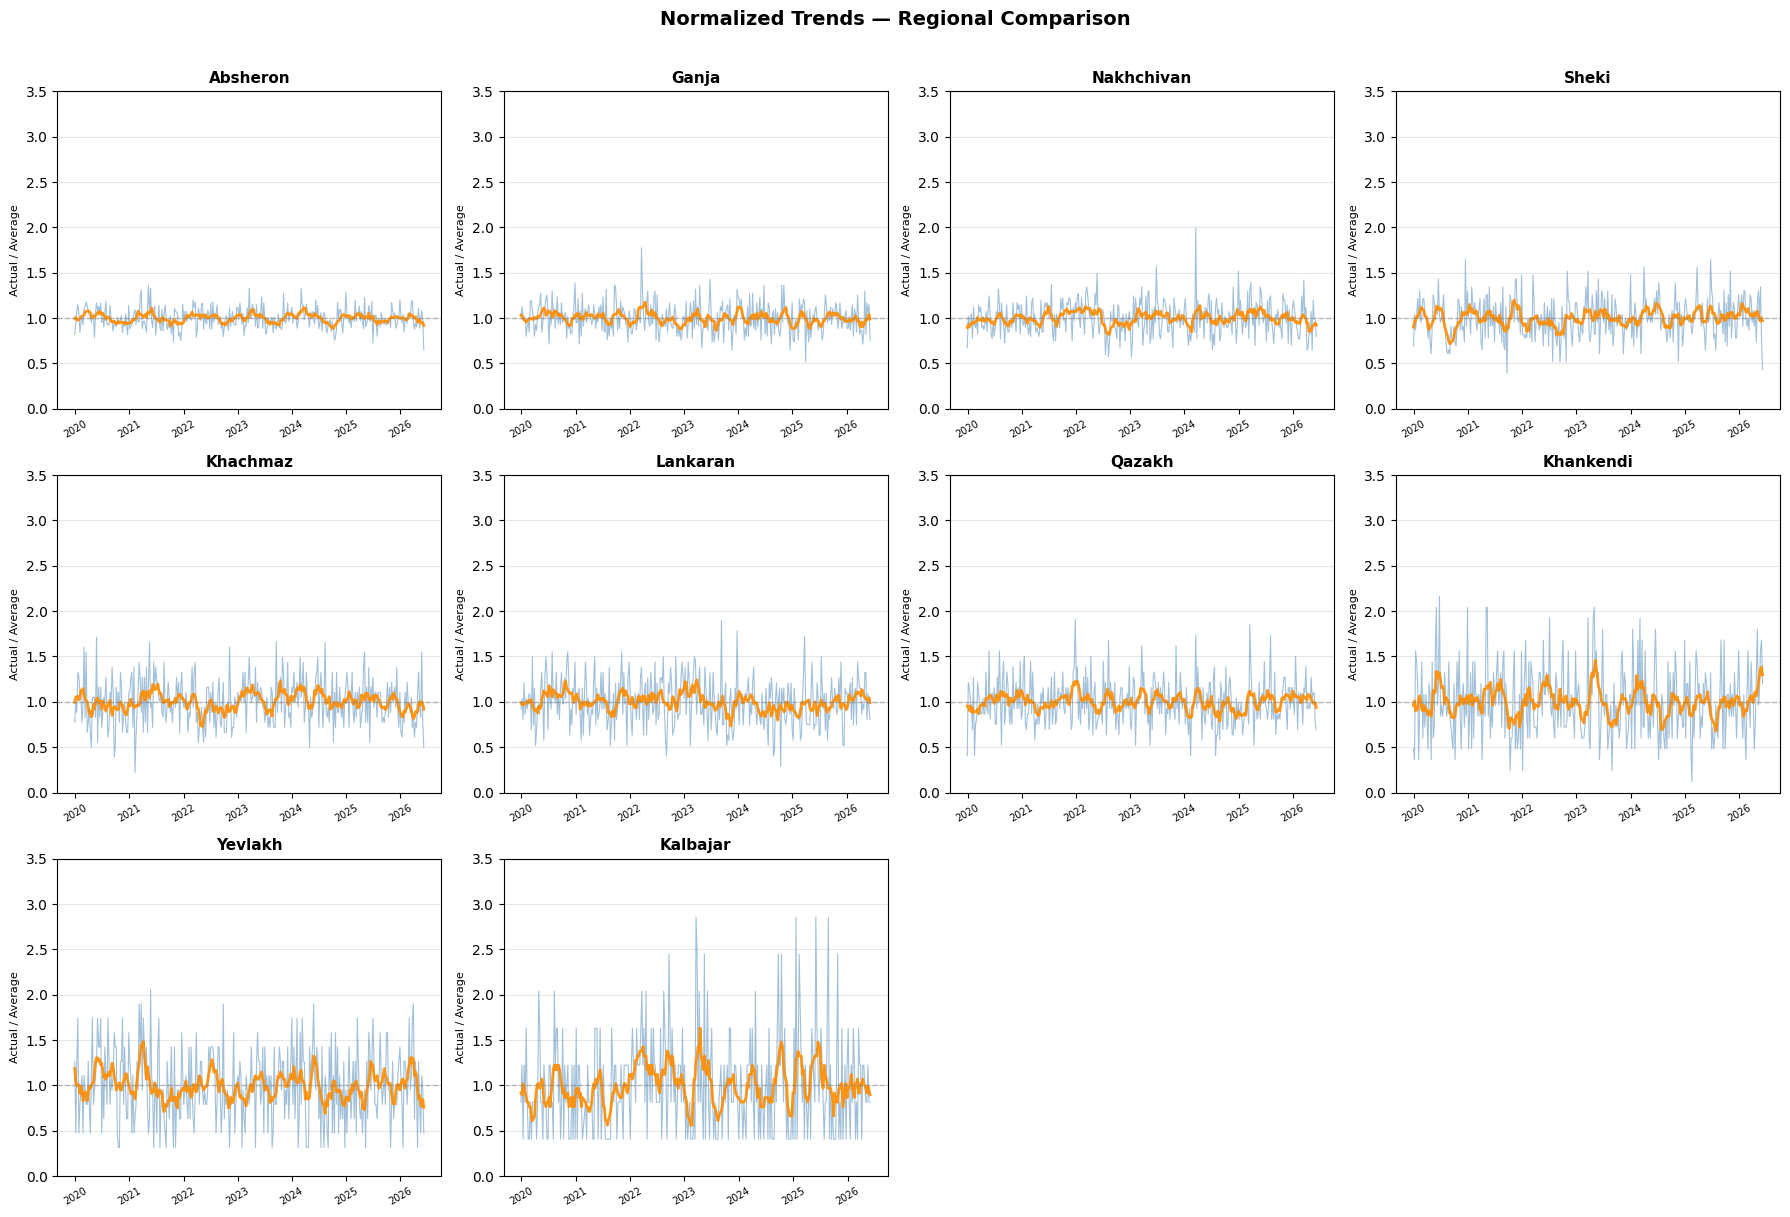

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Normalized Trends — Regional Comparison',
             fontsize=14, fontweight='bold', y=1.01)

axes_flat = axes.flatten()

for i, region in enumerate(regions_sorted):
    ax  = axes_flat[i]
    sub = weekly[weekly['region'] == region].sort_values('week')

    normalized = sub['order_count'] / sub['order_count'].mean()
    rolling    = normalized.rolling(8, center=True, min_periods=3).mean()

    ax.plot(sub['week'], normalized,
            linewidth=0.8, color='steelblue', alpha=0.5)
    ax.plot(sub['week'], rolling,
            linewidth=2, color='darkorange', alpha=0.9)

    ax.axhline(1.0, color='gray', linewidth=1,
               linestyle='--', alpha=0.5)

    ax.set_title(region, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 3.5)
    ax.set_ylabel('Actual / Average', fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.grid(axis='y', alpha=0.3)

for j in range(len(regions_sorted), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

In [10]:
lines = ["# Regional Patterns — E-01 Summary\n"]

for region in regions_sorted:
    sub  = weekly[weekly['region'] == region]
    peak_month = (sub.groupby(sub['week'].dt.month)['order_count']
                  .mean().idxmax())
    cv_val = sub['order_count'].std() / sub['order_count'].mean()

    grade = 'A' if cv_val < 0.4 else ('B' if cv_val < 0.7 else 'C')

    lines.append(f"## {region}")
    lines.append(f"- Average weekly orders : {sub['order_count'].mean():.1f}")
    lines.append(f"- Variation (CV)         : {cv_val:.2f}  → Quality: {grade}")
    lines.append(f"- Peak month             : {month_names[peak_month]}")
    lines.append(f"- Number of weeks       : {len(sub)}\n")

report = "\n".join(lines)
print(report)

# Regional Patterns — E-01 Summary

## Absheron
- Average weekly orders : 147.3
- Variation (CV)         : 0.11  → Quality: A
- Peak month             : Mar
- Number of weeks       : 337

## Ganja
- Average weekly orders : 46.2
- Variation (CV)         : 0.16  → Quality: A
- Peak month             : Mar
- Number of weeks       : 337

## Nakhchivan
- Average weekly orders : 40.1
- Variation (CV)         : 0.18  → Quality: A
- Peak month             : Mar
- Number of weeks       : 337

## Sheki
- Average weekly orders : 23.1
- Variation (CV)         : 0.22  → Quality: A
- Peak month             : Mar
- Number of weeks       : 337

## Khachmaz
- Average weekly orders : 18.1
- Variation (CV)         : 0.25  → Quality: A
- Peak month             : Mar
- Number of weeks       : 337

## Lankaran
- Average weekly orders : 17.4
- Variation (CV)         : 0.26  → Quality: A
- Peak month             : Mar
- Number of weeks       : 337

## Qazakh
- Average weekly orders : 17.3
- Variation (CV)    

# EDA Summary

The exploratory analysis successfully transformed the raw order data into weekly regional time series.

The findings below summarize the current state of the dataset and prepare it for the next stage of the project.

In [12]:
highest_avg = stats["orta"].idxmax()
lowest_avg = stats["orta"].idxmin()
highest_cv = stats["cv"].idxmax()

missing_region_count = (
    missing_df["region"].nunique()
    if not missing_df.empty
    else 0
)

print("EDA SUMMARY")

print(f"Regions Analysed        : {weekly['region'].nunique()}")
print(f"Total Weekly Records    : {len(weekly)}")
print(f"Highest Average Demand  : {highest_avg}")
print(f"Lowest Average Demand   : {lowest_avg}")
print(f"Most Volatile Region    : {highest_cv}")
print(f"Regions with Data Gaps  : {missing_region_count}")


EDA SUMMARY
Regions Analysed        : 10
Total Weekly Records    : 3340
Highest Average Demand  : Absheron
Lowest Average Demand   : Kalbajar
Most Volatile Region    : Kalbajar
Regions with Data Gaps  : 2
